## Build a basic chatbot with Langgraph ( GRAPH API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages] 

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

False

In [5]:
## define the node i.e the chatbot
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    api_key="Enter API key",
    base_url="https://openrouter.ai/api/v1",
    model="google/gemini-2.0-flash-001",
    default_headers={
        "HTTP-Referer": "http://localhost:3000",
        "X-Title": "F1 SQL Agent",
    },
    temperature=0 
)


In [6]:
llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x7783b31e9400>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7783b31e9e80>, root_client=<openai.OpenAI object at 0x7783e2736120>, root_async_client=<openai.AsyncOpenAI object at 0x7783b31e9be0>, model_name='google/gemini-2.0-flash-001', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://openrouter.ai/api/v1', default_headers={'HTTP-Referer': 'http://localhost:3000', 'X-Title': 'F1 SQL Agent'})

In [7]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}
##As soon as we get the message from the user, we give it as input to the chatbot node and get the response from the llm and add it to the messages list


In [8]:
## Adding node
graph_builder.add_node('chatbot', chatbot) ## created a node named chatbot and added the functionality to it

## Adding edges
graph_builder.add_edge(START,'chatbot')
graph_builder.add_edge('chatbot',END)

#compiling the graph
graph = graph_builder.compile()

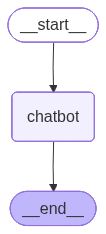

In [9]:
## visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)

In [10]:
response=graph.invoke({"messages":["Hi"]})
response["messages"][-1].content ## retrives the last message in the messages list which is the response from the llm

'Hi there! How can I help you today?\n'

## Chatbot with Tool

In [11]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

# Set the environment variable
os.environ["TAVILY_API_KEY"] = "Enter API key"

# Initialize the tool (it will automatically find the key above)
tool = TavilySearchResults(max_results=2)

# Invoke
tool.invoke("What is Langgraph?")

/tmp/ipykernel_944662/1321264970.py:8: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2)


[{'title': 'What is LangGraph - GeeksforGeeks',
  'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/',
  'content': 'Interview Prep\n\n Python for Machine Learning\n Machine Learning with R\n Machine Learning Algorithms\n EDA\n Math for Machine Learning\n Machine Learning Interview Questions\n ML Projects\n Deep Learning\n NLP\n Computer vision\n Data Science\n Artificial Intelligence\n\n# What is LangGraph?\n\nLast Updated : 12 Dec, 2025\n\nLangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. [...] ## Building a Simple Chatbot with LangGraph\n\nLangGraph makes it easy to build structured, stateful applications like chatbots. In this example we’ll learn how to create a basic chatbot that can classify user input

In [12]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [13]:
# tool definition 
tools=[tool,multiply]

# Binding the tool with the llm
llm_with_tools = llm.bind_tools(tools)

llm_with_tools

RunnableBinding(bound=ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x7783b31e9400>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7783b31e9e80>, root_client=<openai.OpenAI object at 0x7783e2736120>, root_async_client=<openai.AsyncOpenAI object at 0x7783b31e9be0>, model_name='google/gemini-2.0-flash-001', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://openrouter.ai/api/v1', default_headers={'HTTP-Referer': 'http://localhost:3000', 'X-Title': 'F1 SQL Agent'}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search_results_json', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'search query to look up', 'type': 'string'}}, 'required': ['q

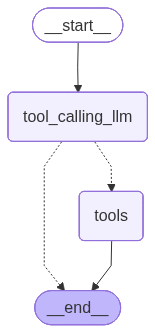

In [14]:
from langgraph.prebuilt import ToolNode,tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
response=graph.invoke({"messages":"What is the recent ai news"})
response["messages"][-1].content

'[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com/", "content": "### SAP brings agentic AI to human capital management\\n\\nAI Business Strategy, AI in Action, Artificial Intelligence, Featured News, Features, Physical AI\\n\\n### Hyundai expands into robotics and physical AI systems\\n\\nAI Business Strategy, AI Market Trends, Cybersecurity AI, Data Engineering & MLOps, Deep Dives, Featured News, Features, Governance, Regulation & Policy, Infrastructure & Hardware, Inside AI, Open-Source & Democratised AI, Opinion, TechEx Events, Trust, Bias & Fairness, World of Work\\n\\n### IBM: How robust AI governance protects enterprise margins\\n\\nArtificial Intelligence, Cybersecurity AI, Featured News, Finance AI, TechEx Events\\n\\n### Experian uncovers fraud paradox in financial services’ AI adoption\\n\\n## Latest\\n\\nMultimodal AI\\n\\nApril 15, 2026 [...] #### Applications\\n\\n### Thailand becomes one 

In [16]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (tool_tavily_search_results_json_ybXEGLrmpw8vK6vcpqVx)
 Call ID: tool_tavily_search_results_json_ybXEGLrmpw8vK6vcpqVx
  Args:
    query: recent AI news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com/", "content": "### SAP brings agentic AI to human capital management\n\nAI Business Strategy, AI in Action, Artificial Intelligence, Featured News, Features, Physical AI\n\n### Hyundai expands into robotics and physical AI systems\n\nAI Business Strategy, AI Market Trends, Cybersecurity AI, Data Engineering & MLOps, Deep Dives, Featured News, Features, Governance, R

## ReAct Architecture

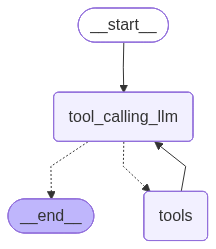

In [17]:
from langgraph.prebuilt import ToolNode,tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
##Instead of routing to end we route it back to the llm node so that it can take the output from the tool and give the final response to the user
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
response=graph.invoke({"messages":"What is the recent ai news and multiply 5 by 10"})
response["messages"][-1].content
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news and multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (tool_tavily_search_results_json_rk0x4FTcozel0ju8jlc6)
 Call ID: tool_tavily_search_results_json_rk0x4FTcozel0ju8jlc6
  Args:
    query: recent AI news
  multiply (tool_multiply_XQZkw9QS9KwBHgjcNaL7)
 Call ID: tool_multiply_XQZkw9QS9KwBHgjcNaL7
  Args:
    b: 10
    a: 5
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com/", "content": "### SAP brings agentic AI to human capital management\n\nAI Business Strategy, AI in Action, Artificial Intelligence, Featured News, Features, Physical AI\n\n### Hyundai expands into robotics and physical AI syst

## Adding memory in Agentic Graph

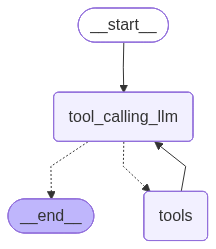

In [19]:
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm") ##Instead of routing to end we route it back to the llm node so that it can take the output from the tool and give the final response to the user

## compile the graph
## We add the memory to the compile step so that it can save the state of the graph after every execution in the memory
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Sahithi"},config=config)

response["messages"][-1].content

'Hello Sahithi, nice to meet you!\n'

In [21]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes, your name is Sahithi.



## Streaming

In [22]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

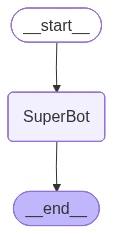

In [23]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [24]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Krish, it's great to meet you! Cricket is a fantastic sport. Do you have a favorite team or player? What do you enjoy most about watching or playing cricket?\n", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 10, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 1.62e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 1.62e-05, 'upstream_inference_prompt_cost': 1e-06, 'upstream_inference_completions_cost': 1.52e-05}}, 'model_provider': 'openai', 'model_name': 'google/gemini-2.0-flash-001', 'system_fingerprint': None, 'id': 'gen-1776426523-5aEbtpa74G8eZ5r1XNS2', 'finish_reason': 'stop', 'logprobs': None}, id='l

In [25]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='c7331cec-6a71-410b-90ff-ae2d0e3c2121'), AIMessage(content="Hi Krish, it's great to meet you! Cricket is a fantastic sport. Do you have a favorite team or player? What do you enjoy most about watching or playing cricket?\n", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 10, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 1.62e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 1.62e-05, 'upstream_inference_prompt_cost': 1e-06, 'upstream_inference_completions_cost': 1.52e-05}}, 'model_provider': 'openai', 'model_name': 'google/gemini-

## Human feedback in the loop

In [34]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [35]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

In [36]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (tool_human_assistance_pTRGlxmPefLIq8IFrbas)
 Call ID: tool_human_assistance_pTRGlxmPefLIq8IFrbas
  Args:
    query: I need expert guidance and assistance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (tool_human_assistance_pTRGlxmPefLIq8IFrbas)
 Call ID: tool_human_assistance_pTRGlxmPefLIq8IFrbas
  Args:
    query: I need expert guidance and assistance for building an AI agent.


In [37]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (tool_human_assistance_pTRGlxmPefLIq8IFrbas)
 Call ID: tool_human_assistance_pTRGlxmPefLIq8IFrbas
  Args:
    query: I need expert guidance and assistance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

OK. The experts recommend that you check out LangGraph to build your agent. They say it is much more reliable and extensible than simple autonomous agents.
